In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: False


#### Loading dataset with confidence function (SR)

In [2]:
sgp_df_SR = pickle.load(open("sgp_set_resnet", "rb"))
print(
    "N =", sgp_df_SR.shape[0], "1s prop = ", sgp_df_SR.y_true.sum() / sgp_df_SR.shape[0]
)
sgp_df_SR.head(3)

N = 40000 1s prop =  0.09895


,y_true,y_pred,kappa
0,0.0,0.0,0.999986
1,0.0,0.0,0.999986
2,0.0,0.0,0.999990


#### Random split into bounds-fitting and bounds-testing (with reproducible seed)

In [3]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=17
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing

Setting experiments parameters

In [4]:
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grid

In [5]:
color_map = {
    "standard": "#d51414",
    "FP": "#8F7A1C",
    "FN": "#0f770a",
    "FPR": "#403535",
    "FNR": "#1d3ae2",
    "SE": "#93139c",
    "SP": "#0F8592",
    "PPV": "#676767",
}

#### Joint evolution of metrics with respect to $\theta$

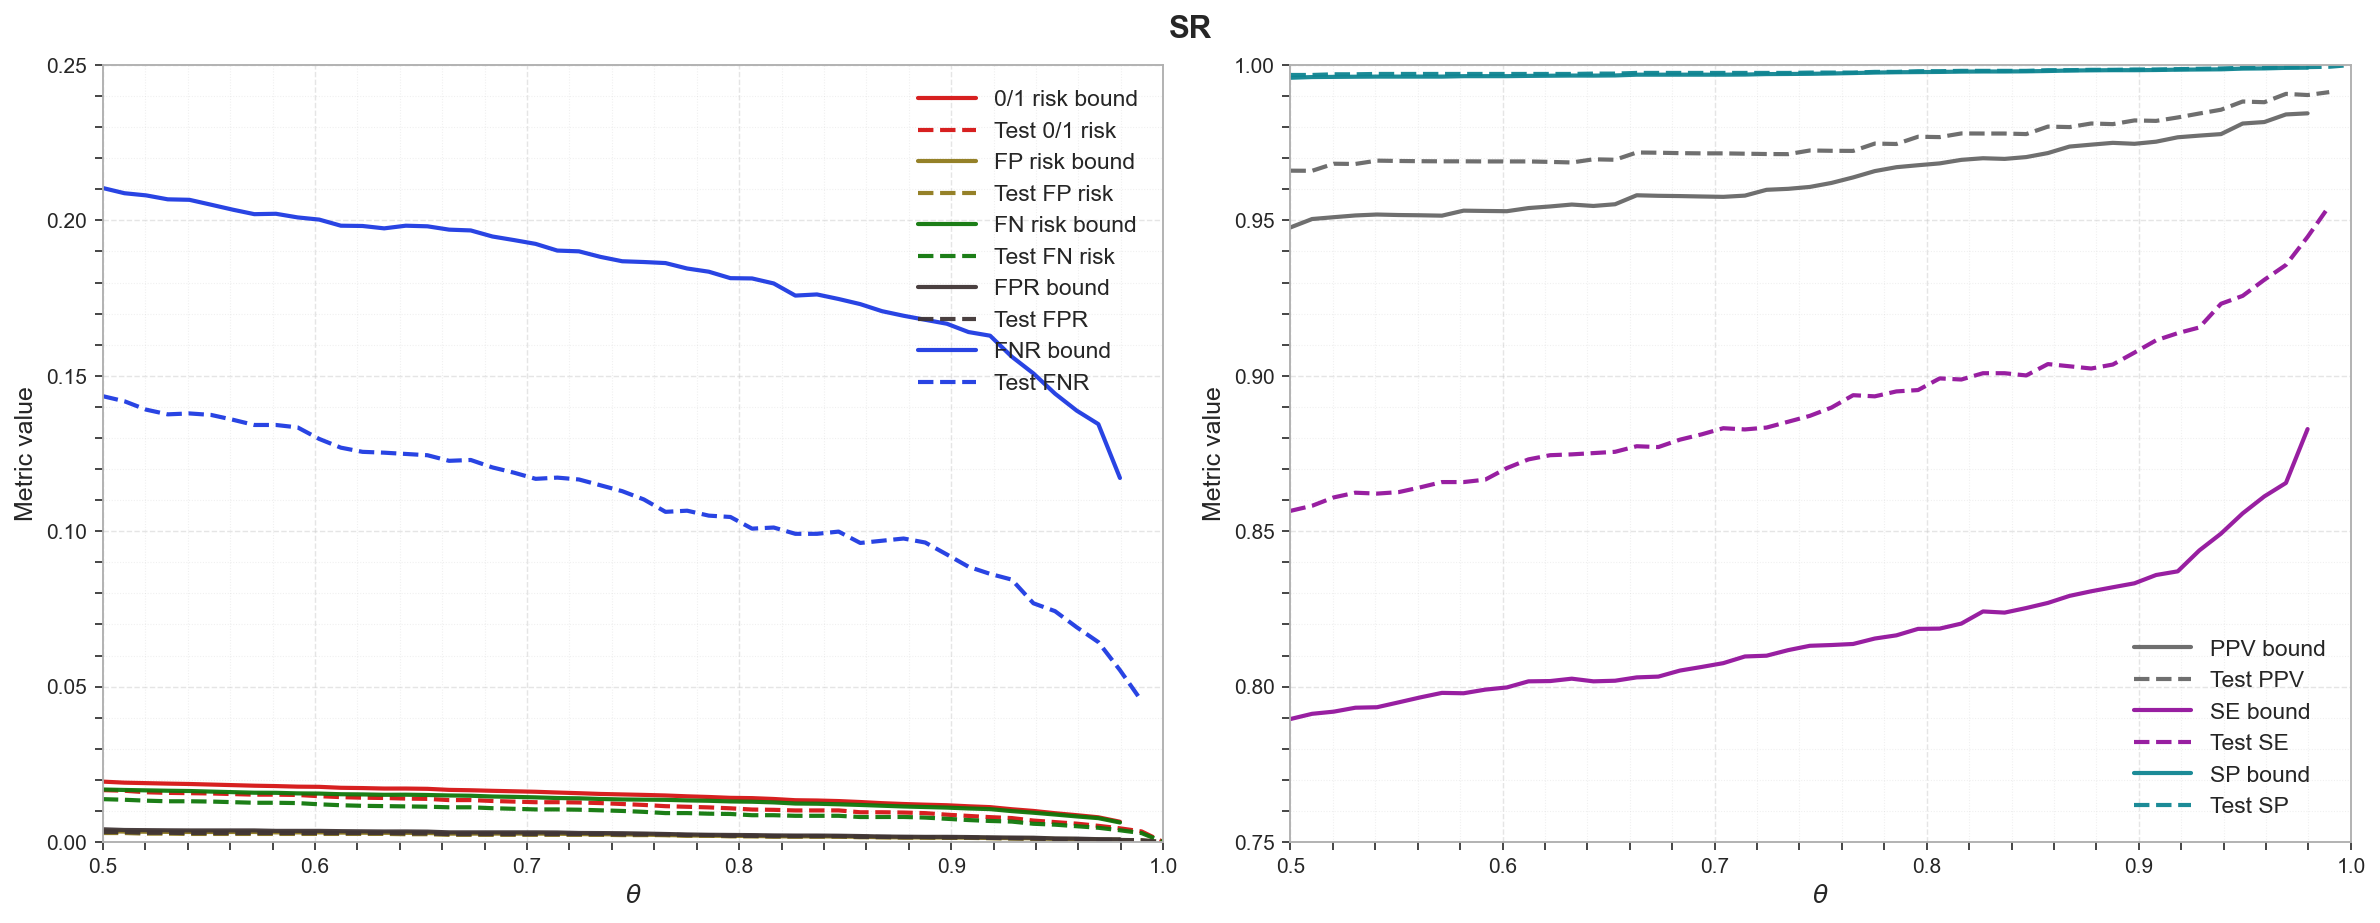

In [6]:
plot_all_metrics(
    train_set_SR,
    test_set_SR,
    color_map,
    title="SR",
    ylim1=[0, 0.25],
    ylim2=[0.75, 1],
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)

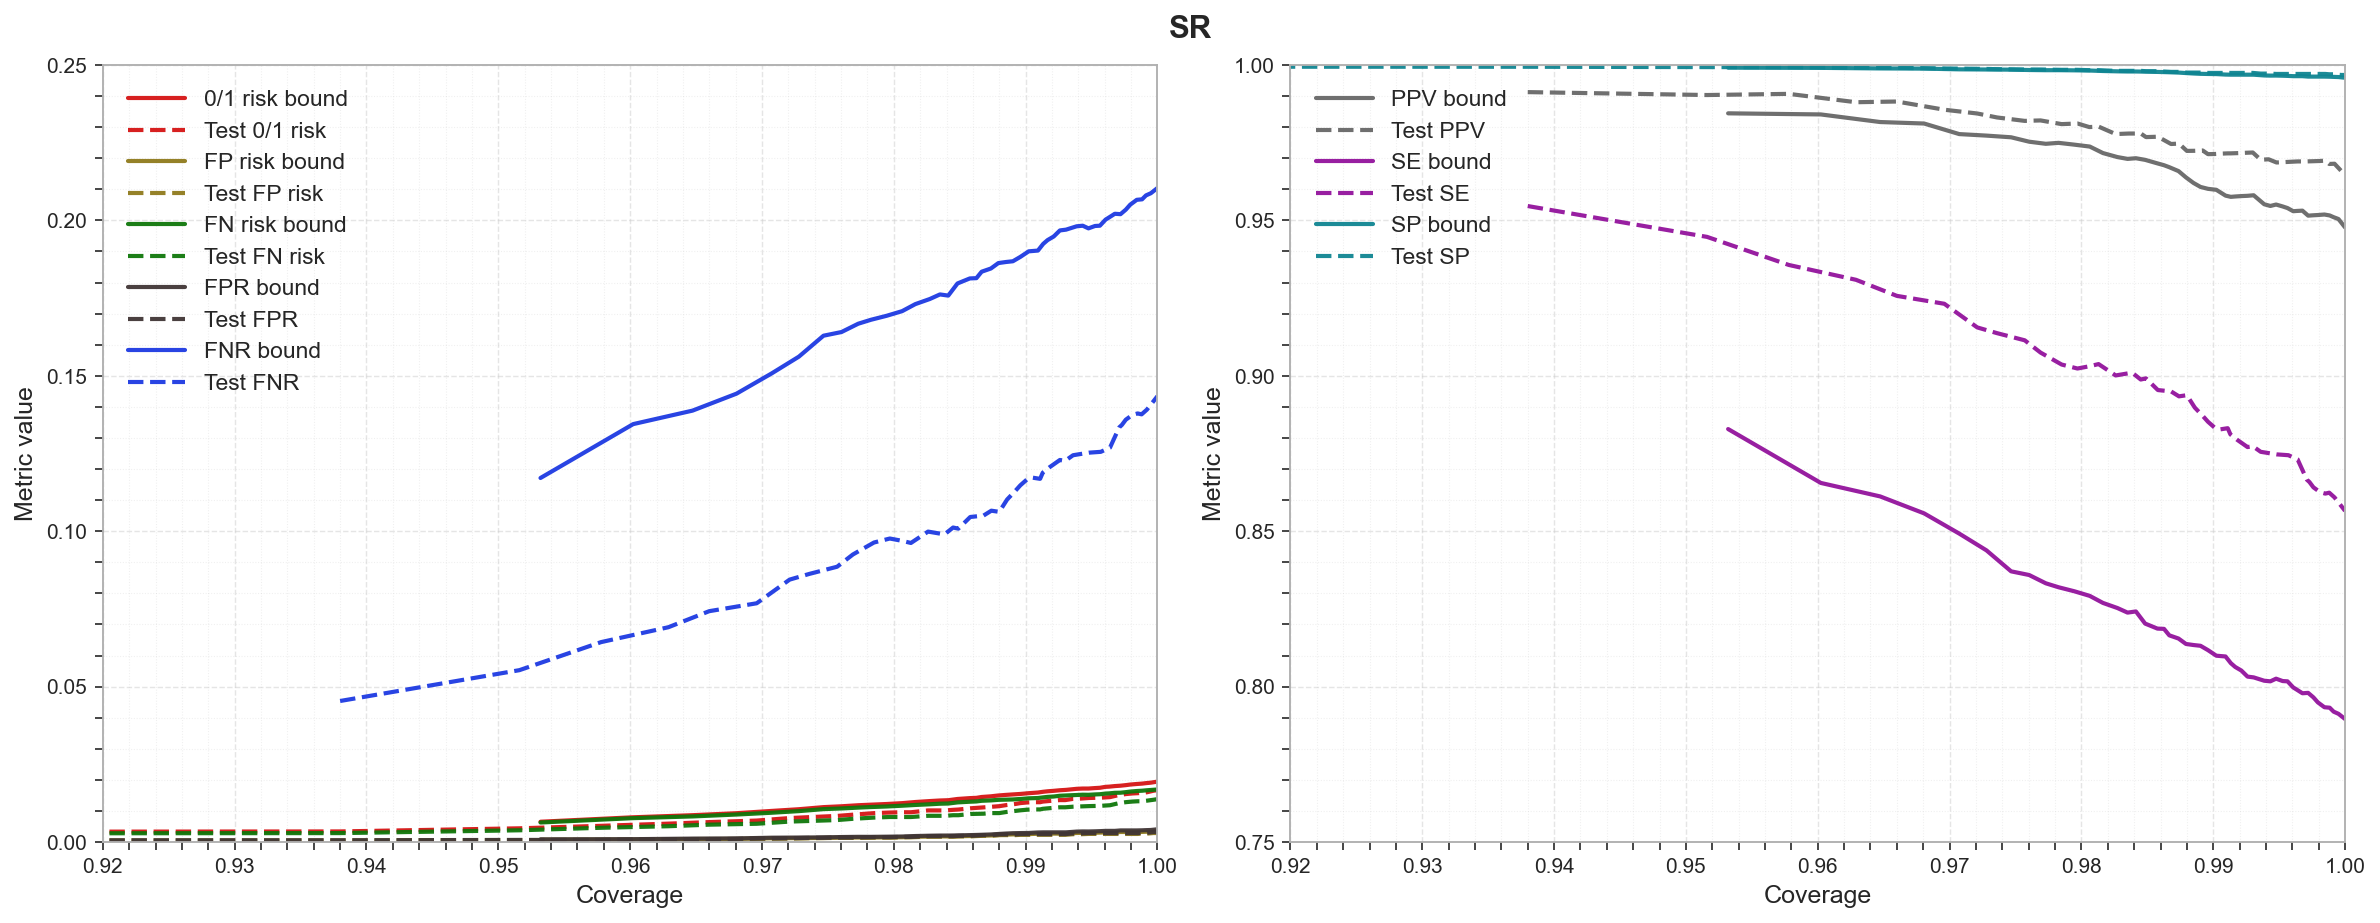

In [7]:
plot_all_metrics(
    train_set_SR,
    test_set_SR,
    color_map,
    title="SR",
    ylim1=[0, 0.25],
    ylim2=[0.75, 1],
    xlim1=[0.92, 1],
    xlim2=[0.92, 1],
    by_coverage=True,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)

#### Finding $\theta^*$ for joint control, if solutions set is non empty

In [8]:
metrics_and_targets = {"FNR": 0.2, "FPR": 0.1}

In [9]:
joint_output = joint_control(
    metrics_and_targets,
    train_set_SR,
    plot=False,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
joint_output

{'theta_intervals': [(np.float64(0.6122448979591837),
   np.float64(0.9795918367346939))],
 'best_theta': np.float64(0.6122448979591837)}

#### Displaying all bounds trade-offs for a couple of 2 metrics

In [10]:
metrics = ["standard", "FP", "FN", "FPR", "FNR", "PPV", "SE", "SP"]

all_bounds_SR = reachable_bounds(
    metrics, train_set_SR, theta_min=theta_min_SR, theta_max=theta_max_SR
)

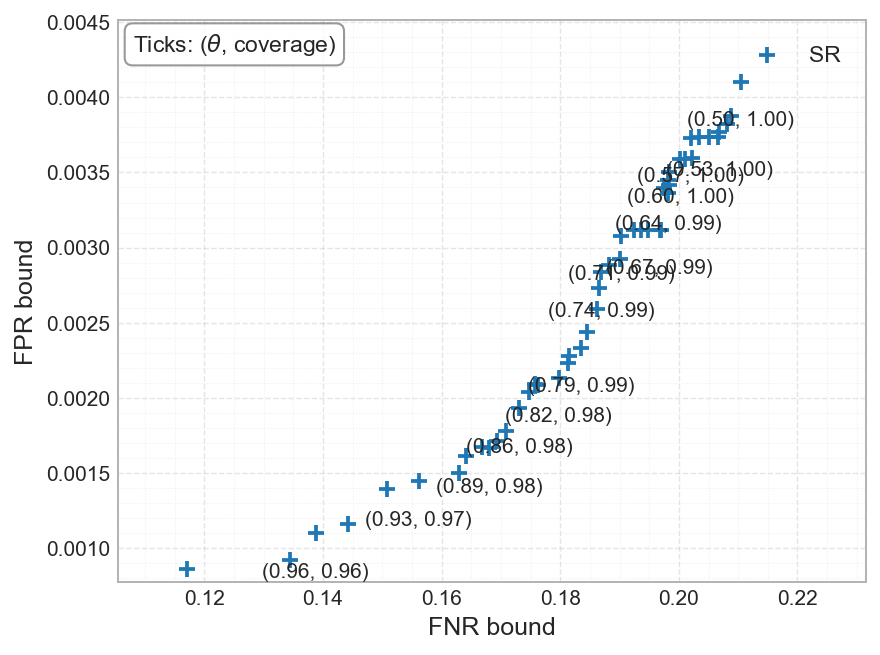

In [12]:
metric1 = "FNR"
metric2 = "FPR"

two_metrics_bounds(metric1, metric2, all_bounds_SR, all_bounds_MCD=None, num_labels=15)